# Feature Exploration: Real & Synthetic Datasets

This notebook explores features extracted from process models and traces using both real XES datasets and synthetic process models.

## Overview
- Creates RunDatasets from real XES event logs
- Creates synthetic RunDatasets with controlled configurations
- Extracts comprehensive features for each model-trace combination
- Visualizes Petri nets and displays features

## 1. Setup & Imports

In [1]:
from pathlib import Path
import sys
import os

notebook_dir = Path.cwd()
if notebook_dir.name == "experiments":
    project_root = notebook_dir.parent
    os.chdir(project_root)
    sys.path.insert(0, str(project_root))
    print(f"Working directory set to: {project_root}")
else:
    print(f"Current directory: {notebook_dir}")

from pm4py.objects.petri_net.utils.petri_utils import construct_trace_net
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.discovery import discover_petri_net_inductive

from dataloaders.xes_log import XESEventLogDataset
from dataloaders.net import ProcessModelDataset, VariantRandomDistributionSampler
from dataloaders.unique_net import UniqueProcessModelDataset
from dataloaders.runs import RunDataset, AlignerSpec, SimplePerturbedTraceSampler, SyntheticTraceSampler
from dataloaders.synthetic import SyntheticProcessModelDataset
from deduplication.deduplicator import DeduplicationConfig
from features import CompositeFeatureExtractor
from util.distributions import CategoricalSpec, PoissonSpec, BernoulliDepthLinearSpec, ExponentialSpec, NormalSpec
from util.rng import RNG

import warnings
warnings.filterwarnings('ignore')

Working directory set to: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25


In [2]:
# Enable automatic module reloading
%load_ext autoreload
%autoreload 2

print("Autoreload enabled - modules will be reloaded automatically when changed")

Autoreload enabled - modules will be reloaded automatically when changed


In [3]:
# Configuration
MAX_COMBINATIONS_TO_DISPLAY = 20
RANDOM_SEED = 42
RNG.initialize(RANDOM_SEED)

DATA_DIR = Path("data")
CACHE_DIR = Path("cache")

## 2. Real Dataset Processing

Processing real XES event logs with inductive miner discovery.

In [4]:
# Real datasets to process
REAL_DATASETS = {
    'd9769f3d-0ab0-4fb8-803b-0d1120ffcf54': ['Hospital_log.xes'],
    'a0addfda-2044-4541-a450-fdcc9fe16d17': ['BPIC15_1.xes'],
    'b32c6fe5-f212-4286-9774-58dd53511cf8': ['BPIC15_5.xes'],
    '5f3067df-f10b-45da-b98b-86ae4c7a310b': ['BPI%20Challenge%202017.xes'],
    'db35afac-2133-40f3-a565-2dc77a9329a3': ['PermitLog.xes'],
    '6a0a26d2-82d0-4018-b1cd-89afb0e8627f': ['DomesticDeclarations.xes'],
    'c2c3b154-ab26-4b31-a0e8-8f2350ddac11': ['BPI_Challenge_2013_closed_problems.xes'],
}

real_run_datasets = []

In [5]:
# Process each real dataset
dedup_config = DeduplicationConfig()

for dataset_uuid, files in REAL_DATASETS.items():
    for filename in files:
        print(f"Processing: {filename}")
        
        dataset_path = DATA_DIR / dataset_uuid / filename
        
        log_dataset = XESEventLogDataset(str(dataset_path), attribute="concept:name")
        
        pm_dataset = ProcessModelDataset(
            log_dataset=log_dataset,
            discovery_methods={"inductive": discover_petri_net_inductive},
            param_grid={
                "noise_threshold": [0.0, 0.2],
                "disable_fallthroughs": [True],
            },
            sampler_specs={
                "variant_random": VariantRandomDistributionSampler(
                    seed=1,
                    n_subsets=5,
                    max_len_subset=100,
                    min_len_subset=10,
                    len_distribution=ExponentialSpec(rate=1.0 / 100.0),
                    freq_distribution=NormalSpec(mean=10.0, std=5.0),
                    reconstruct_frequency=True,
                )
            },
            cached=True,
            max_models=3,
        )
        
        unique_dataset = UniqueProcessModelDataset(
            base_dataset=pm_dataset,
            dedup_config=dedup_config,
            force_recompute=False,
        )
        
        sampler = SimplePerturbedTraceSampler(
            seed=42,
            ds=unique_dataset,
            slice=range(0, 3)
        )
        
        run_base_path = CACHE_DIR / "run_datasets" / filename.replace('.xes', '')
        run_base_path.mkdir(parents=True, exist_ok=True)
        
        run_dataset = RunDataset(
            base_path=run_base_path,
            process_model_dataset=unique_dataset,
            aligners=AlignerSpec.A_STAR.value,
            trace_sampler=sampler,
            n_runs=1,
        )
        
        real_run_datasets.append((filename, run_dataset))
        print(f"  Created RunDataset with {len(run_dataset)} items\n")

print(f"Total real RunDatasets: {len(real_run_datasets)}")

Processing: Hospital_log.xes


parsing log, completed traces :: 100%|██████████| 1143/1143 [00:02<00:00, 463.76it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 13 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (13 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 3 unique indices from cache (cache/.cache_unique_models/unique_dedup_bdd5a0f78a103bf4.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 8192.00it/s]
INFO:root:Deduplication complete. Kept 3 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_bdd5a0f78a103bf4.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 450
INFO:root:Populating run dataset 


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           3
Duplicates found:            0
Reduction:                   0.0%

COMPARISON STATISTICS:
  Total comparisons:         3
  Passed stage 1 (labels):   0
  Passed stage 2 (combined): 0

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/45 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 45 items

Processing: BPIC15_1.xes


parsing log, completed traces :: 100%|██████████| 1199/1199 [00:01<00:00, 1170.77it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 13 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (13 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 3 unique indices from cache (cache/.cache_unique_models/unique_dedup_0dca14ad092b4f93.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 11145.18it/s]
INFO:root:Deduplication complete. Kept 3 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_0dca14ad092b4f93.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 95
INFO:root:Populating run dataset


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           3
Duplicates found:            0
Reduction:                   0.0%

COMPARISON STATISTICS:
  Total comparisons:         3
  Passed stage 1 (labels):   0
  Passed stage 2 (combined): 0

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/45 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 45 items

Processing: BPIC15_5.xes


parsing log, completed traces :: 100%|██████████| 1156/1156 [00:01<00:00, 1002.00it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 3 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (3 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 3 unique indices from cache (cache/.cache_unique_models/unique_dedup_41738fbb532e1000.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 10246.67it/s]
INFO:root:Deduplication complete. Kept 3 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_41738fbb532e1000.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 45
INFO:root:Populating run dataset c


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           3
Duplicates found:            0
Reduction:                   0.0%

COMPARISON STATISTICS:
  Total comparisons:         3
  Passed stage 1 (labels):   0
  Passed stage 2 (combined): 0

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/45 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 45 items

Processing: BPI%20Challenge%202017.xes


parsing log, completed traces :: 100%|██████████| 31509/31509 [00:13<00:00, 2321.00it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 3 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (3 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 1 unique indices from cache (cache/.cache_unique_models/unique_dedup_fc237fbec952eea3.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 1413.02it/s]
INFO:root:Deduplication complete. Kept 1 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_fc237fbec952eea3.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 15
INFO:root:Populating run dataset 


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           1
Duplicates found:            2
Reduction:                   66.7%

COMPARISON STATISTICS:
  Total comparisons:         2
  Passed stage 1 (labels):   2
  Passed stage 2 (combined): 2

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/15 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 15 items

Processing: PermitLog.xes


parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 8302.02it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 3 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (3 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 3 unique indices from cache (cache/.cache_unique_models/unique_dedup_b9ac70e37a6de407.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 25216.26it/s]
INFO:root:Deduplication complete. Kept 3 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_b9ac70e37a6de407.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 45
INFO:root:Populating run dataset c


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           3
Duplicates found:            0
Reduction:                   0.0%

COMPARISON STATISTICS:
  Total comparisons:         3
  Passed stage 1 (labels):   0
  Passed stage 2 (combined): 0

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/45 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 45 items

Processing: DomesticDeclarations.xes


parsing log, completed traces :: 100%|██████████| 10500/10500 [00:00<00:00, 19756.82it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 3 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (3 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 3 unique indices from cache (cache/.cache_unique_models/unique_dedup_d7a4763cc7a88b37.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 3886.01it/s]
INFO:root:Deduplication complete. Kept 3 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_d7a4763cc7a88b37.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 45
INFO:root:Populating run dataset


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           3
Duplicates found:            0
Reduction:                   0.0%

COMPARISON STATISTICS:
  Total comparisons:         3
  Passed stage 1 (labels):   1
  Passed stage 2 (combined): 0

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/45 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]


  Created RunDataset with 45 items

Processing: BPI_Challenge_2013_closed_problems.xes


parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 10379.57it/s]
INFO:root:Total discovery configurations generated: 3
INFO:root:Loaded 3 models from cache.
INFO:root:Populating process model cache...
Scheduled:   0%|          | 0/3 [00:00<?, ?it/s]
INFO:root:Cache population done (3 models).
Scheduled: 0it [00:00, ?it/s]                   
Discovered: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]
INFO:root:Loaded 2 unique indices from cache (cache/.cache_unique_models/unique_dedup_0e9a35df8497a993.pkl)
INFO:root:Starting deduplication of cached models...
Deduplicating: 100%|██████████| 3/3 [00:00<00:00, 8086.70it/s]
INFO:root:Deduplication complete. Kept 2 unique nets out of 3 total. Report saved to cache/deduplication_report.json
INFO:root:Saved deduplication cache to cache/.cache_unique_models/unique_dedup_0e9a35df8497a993.pkl
INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 30
INFO:root:Populating run dataset c


DEDUPLICATION REPORT (Improved Pipeline)
Total input nets:            3
Final unique nets:           2
Duplicates found:            1
Reduction:                   33.3%

COMPARISON STATISTICS:
  Total comparisons:         2
  Passed stage 1 (labels):   1
  Passed stage 2 (combined): 1

THRESHOLDS:
  Label similarity:          >= 0.95
  Combined similarity:       >= 0.95

STAGES ENABLED:
  Stage 1 (prefilter):       True
  Stage 2 (combined):        True



Scheduled:   0%|          | 0/30 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]

  Created RunDataset with 30 items

Total real RunDatasets: 7


## 3. Synthetic Dataset Processing

Creating synthetic process models with 1 model per configuration.  
Uses the same parameter grid as runs.py but with repetition=1 instead of 20.

In [6]:
# Constants
MIN_DEPTH = 1
MAX_DEPTH = 2

# Synthetic model configurations (same as runs.py but with 1 model per config)
synthetic_param_grid = [
    (
        {  # AND dominant
            "dist_params": {
                "op": CategoricalSpec([0.1, 0.6, 0.2, 0.1]),
                "seq_len": PoissonSpec(4),
                "p_stop": BernoulliDepthLinearSpec(base=0.2, slope=0.1),
                "width": PoissonSpec(3),
            },
            "min_depth": MIN_DEPTH,
            "max_depth": MAX_DEPTH,
        },
        1,
    ),
    (
        {  # XOR dominant
            "dist_params": {
                "op": CategoricalSpec([0.6, 0.1, 0.2, 0.1]),
                "seq_len": PoissonSpec(4),
                "p_stop": BernoulliDepthLinearSpec(base=0.2, slope=0.1),
                "width": PoissonSpec(3),
            },
            "min_depth": MIN_DEPTH,
            "max_depth": MAX_DEPTH,
        },
        1,
    ),
    (
        {  # Shallow and wide XOR dominant
            "dist_params": {
                "op": CategoricalSpec([0.6, 0.1, 0.2, 0.1]),
                "seq_len": PoissonSpec(1),
                "p_stop": BernoulliDepthLinearSpec(base=0.5, slope=0.3),
                "width": PoissonSpec(10),
            },
            "min_depth": MIN_DEPTH,
            "max_depth": MAX_DEPTH,
        },
        1,
    ),
    (
        {  # Shallow and wide XOR/LOOP dominant
            "dist_params": {
                "op": CategoricalSpec([0.4, 0.1, 0.4, 0.1]),
                "seq_len": PoissonSpec(1),
                "p_stop": BernoulliDepthLinearSpec(base=0.5, slope=0.3),
                "width": PoissonSpec(10),
            },
            "min_depth": MIN_DEPTH,
            "max_depth": MAX_DEPTH,
        },
        1,
    ),
    (
        {  # LOOP dominant
            "dist_params": {
                "op": CategoricalSpec([0.15, 0.15, 0.6, 0.1]),
                "seq_len": PoissonSpec(4),
                "p_stop": BernoulliDepthLinearSpec(base=0.2, slope=0.1),
                "width": PoissonSpec(3),
            },
            "min_depth": MIN_DEPTH,
            "max_depth": MAX_DEPTH,
        },
        1,
    ),
]

In [7]:
# Create SyntheticProcessModelDataset
synthetic_dataset = SyntheticProcessModelDataset(param_grid=synthetic_param_grid)

print(f"Created SyntheticProcessModelDataset with {len(synthetic_dataset)} models")

Created SyntheticProcessModelDataset with 5 models


In [8]:
# Create trace sampler for synthetic models
trace_sampler = SyntheticTraceSampler(
    ds=synthetic_dataset,
    seed=RNG.get_seed(),
    batch_size=128,
    slice=range(0, 3),
    steps=40,
)

# Create RunDataset for synthetic models
synthetic_run_base_path = CACHE_DIR / "run_datasets" / "synthetic"
synthetic_run_base_path.mkdir(parents=True, exist_ok=True)

synthetic_run_dataset = RunDataset(
    base_path=synthetic_run_base_path,
    process_model_dataset=synthetic_dataset,
    aligners=AlignerSpec.A_STAR.value,
    trace_sampler=trace_sampler,
    n_runs=1,
)

print(f"Created synthetic RunDataset with {len(synthetic_run_dataset)} items")

INFO:root:Initializing run dataset cache (multiprocessing)...
INFO:root:Current number of items: 65
INFO:root:Populating run dataset cache using 10 workers...
Scheduled:   0%|          | 0/75 [00:00<?, ?it/s]
Scheduled: 0it [00:00, ?it/s]                    
Aligned: 0it [00:00, ?it/s]
Written: 0it [00:00, ?it/s]

Created synthetic RunDataset with 65 items


## 4. Feature Extraction & Visualization

For each model-trace combination, we:
1. Extract the model (Petri net) and trace
2. Construct trace net from the trace
3. Extract all features using CompositeFeatureExtractor
4. Visualize the model and trace net
5. Display features as a dictionary

In [9]:
# Initialize feature extractor
feature_extractor = CompositeFeatureExtractor(use_cache=True)

print(f"Feature extractor initialized with {len(feature_extractor.feature_names)} features")
print(f"\nFeature names: {feature_extractor.feature_names}\n")

Feature extractor initialized with 36 features

Feature names: ['model_n_transitions', 'model_n_places', 'model_n_arcs', 'model_n_inv_transition', 'model_n_dup_transition', 'model_n_uniq_transition', 'model_n_and_split', 'model_n_xor_split', 'model_inv_tran_in_deg_mean', 'model_inv_tran_in_deg_std', 'model_inv_tran_out_deg_mean', 'model_inv_tran_out_deg_std', 'model_uniq_tran_in_deg_mean', 'model_uniq_tran_in_deg_std', 'model_uniq_tran_out_deg_mean', 'model_uniq_tran_out_deg_std', 'model_dup_tran_in_deg_mean', 'model_dup_tran_in_deg_std', 'model_dup_tran_out_deg_mean', 'model_dup_tran_out_deg_std', 'model_place_in_deg_mean', 'model_place_in_deg_std', 'model_place_out_deg_mean', 'model_place_out_deg_std', 'trace_length', 'trace_activity_repeat_mean', 'trace_activity_repeat_std', 'state_space_size', 'interaction_n_activity_present_in_model', 'interaction_n_activity_not_in_model', 'token_replay_trace_is_fit', 'token_replay_trace_fitness', 'token_replay_missing_tokens', 'token_replay_consu

In [10]:
# Helper functions
def display_petri_net(net, im, fm, title="Petri Net", rankdir="LR", max_width=15):
    """
    Display a Petri net visualization with configurable size.
    
    Args:
        net: Petri net
        im: Initial marking
        fm: Final marking
        title: Title for display
        rankdir: Graph direction - "LR" (left-right) or "TB" (top-bottom)
        max_width: Maximum width in inches (default: 6)
    """
    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"{'='*80}")
    
    # Configure visualization parameters
    parameters = {
        pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: "png",
        pn_visualizer.Variants.WO_DECORATION.value.Parameters.RANKDIR: rankdir,
    }
    
    gviz = pn_visualizer.apply(net, im, fm, parameters=parameters)
    
    # Set size attributes for smaller output
    gviz.graph_attr['size'] = f"{max_width},{max_width}"
    gviz.graph_attr['dpi'] = '72'  # Lower DPI = smaller file size
    
    pn_visualizer.view(gviz)

def display_features(features_dict):
    """Display features in a readable format."""
    print(f"\nFeatures:")
    print(f"{'-'*80}")
    for name, value in features_dict.items():
        print(f"  {name:50s}: {value:10.4f}")
    print(f"{'-'*80}\n")

def get_trace_activities(trace):
    """Extract activity names from trace."""
    return [event['concept:name'] for event in trace]


################################################################################
# Combination 1
# Dataset: DomesticDeclarations.xes, Item: 7
################################################################################

Random Sample: DomesticDeclarations.xes - Item 7

Model: Places=14, Transitions=29, Arcs=58
Trace: Length=4, Activities=['Declaration SUBMITTED by EMPLOYEE', 'Declaration FINAL_APPROVED by SUPERVISOR', 'Payment Handled', 'Request Payment']
['t_Declaration SUBMITTED by EMPLOYEE_0', 't_Declaration FINAL_APPROVED by SUPERVISOR_1', 't_Payment Handled_2', 't_Request Payment_3']

Model (Combination 1)


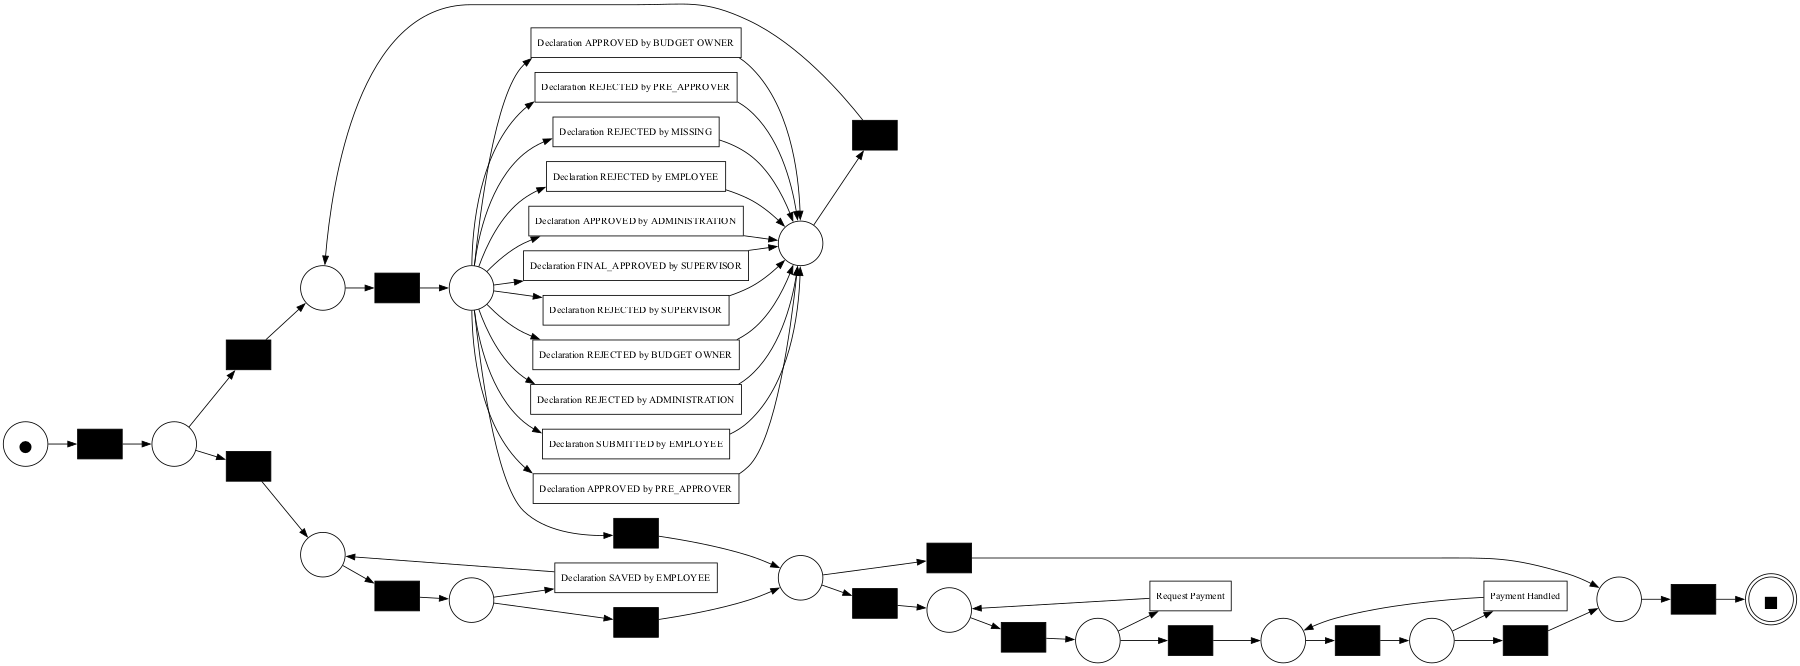


Trace Net (Combination 1)


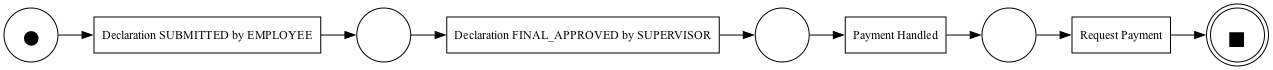


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    29.0000
  model_n_places                                    :    14.0000
  model_n_arcs                                      :    58.0000
  model_n_inv_transition                            :    15.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    14.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     6.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

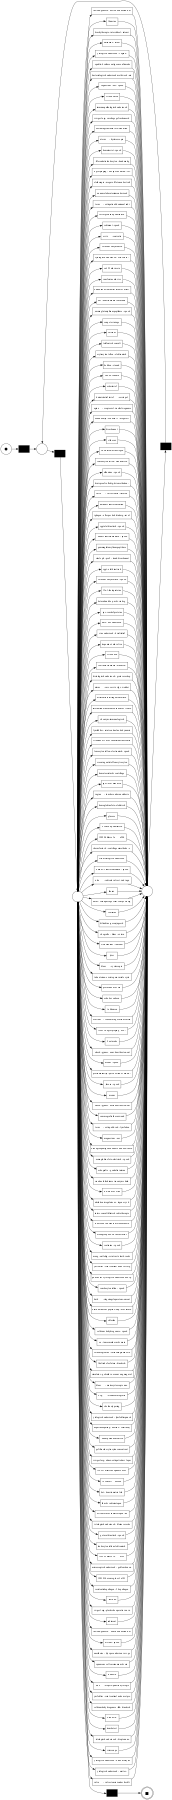


Trace Net (Combination 2)



Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   170.0000
  model_n_places                                    :     5.0000
  model_n_arcs                                      :   340.0000
  model_n_inv_transition                            :     4.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :   166.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

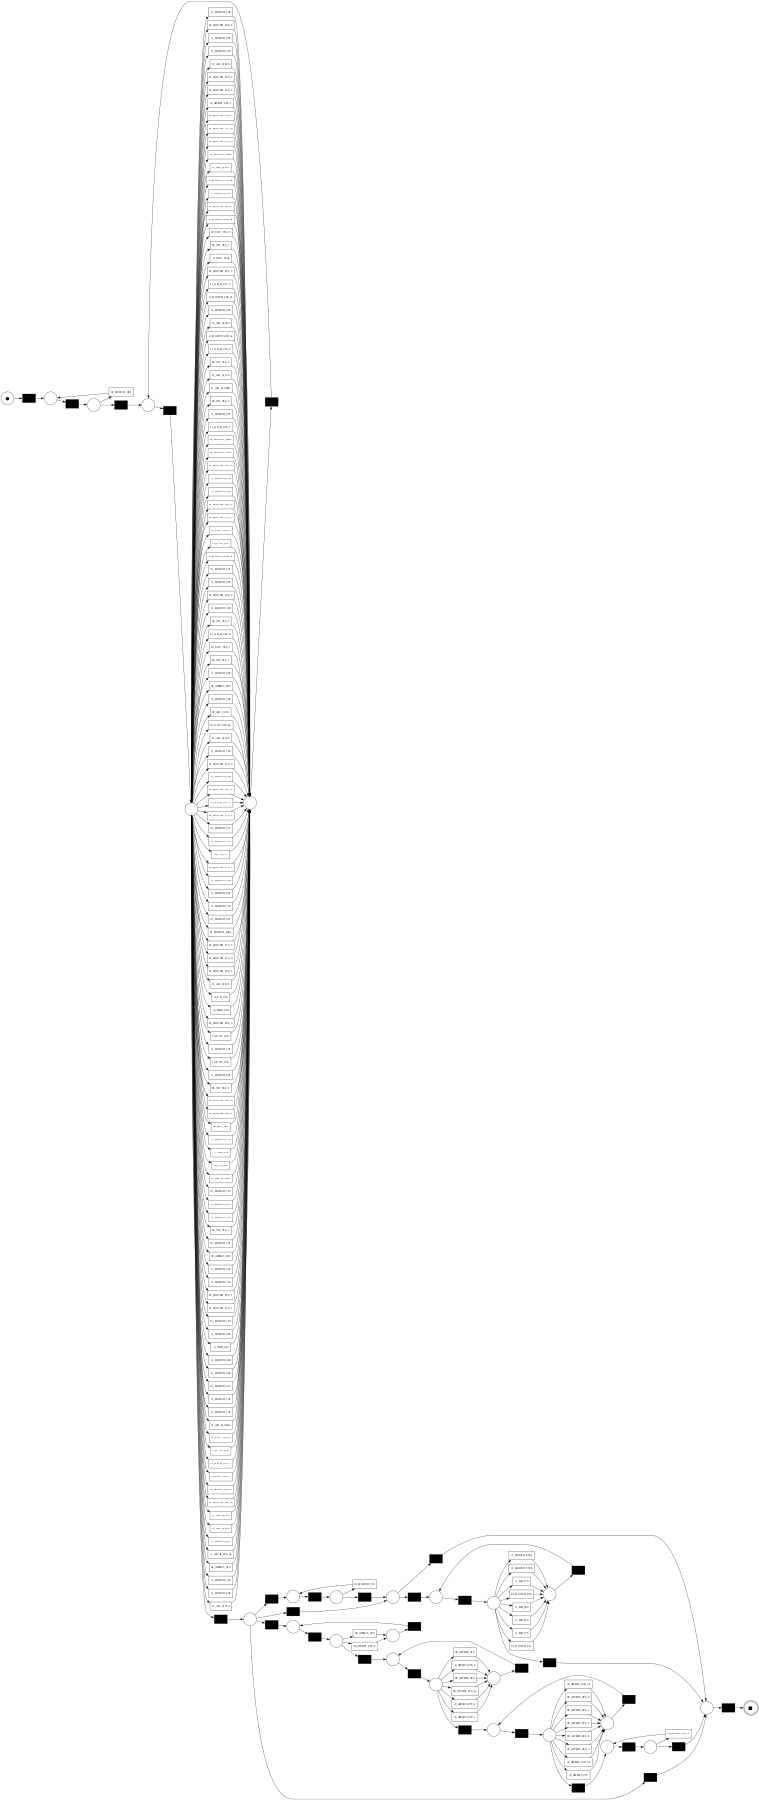


Trace Net (Combination 3)


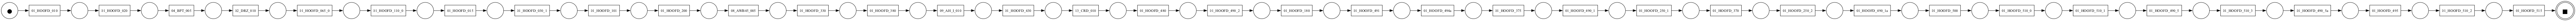


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   180.0000
  model_n_places                                    :    26.0000
  model_n_arcs                                      :   360.0000
  model_n_inv_transition                            :    29.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :   151.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :    10.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

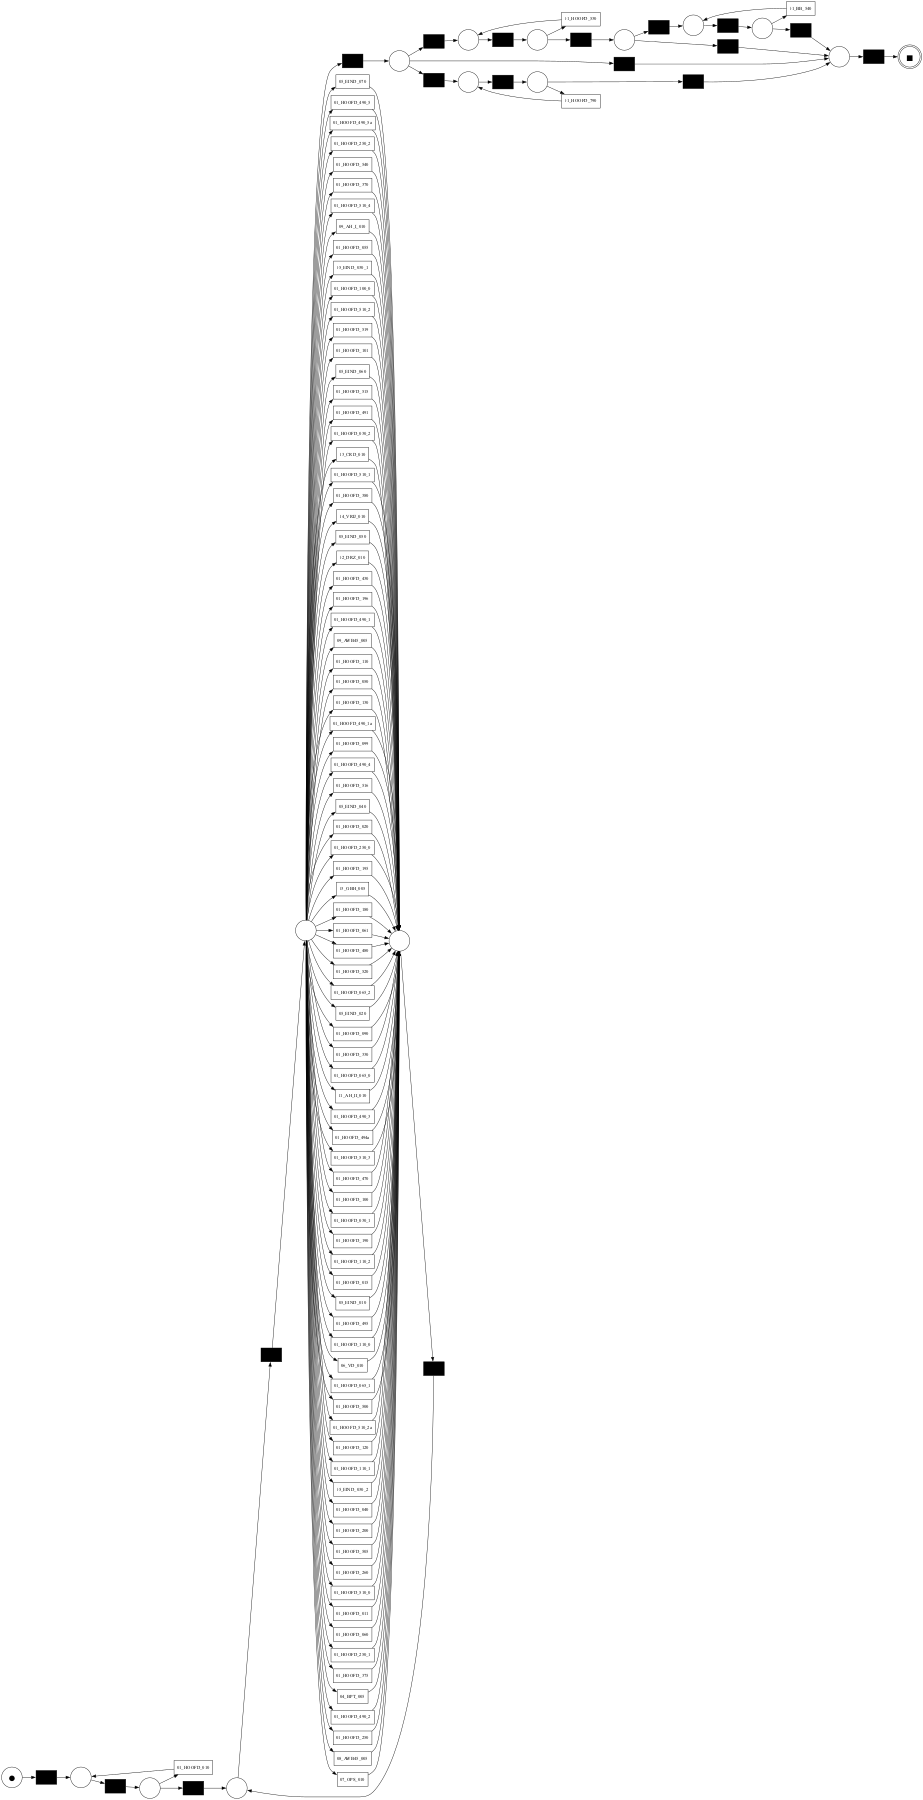


Trace Net (Combination 4)


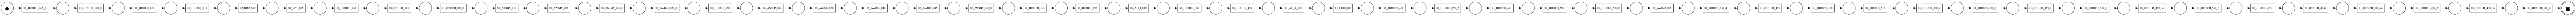


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   105.0000
  model_n_places                                    :    16.0000
  model_n_arcs                                      :   210.0000
  model_n_inv_transition                            :    18.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    87.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     7.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

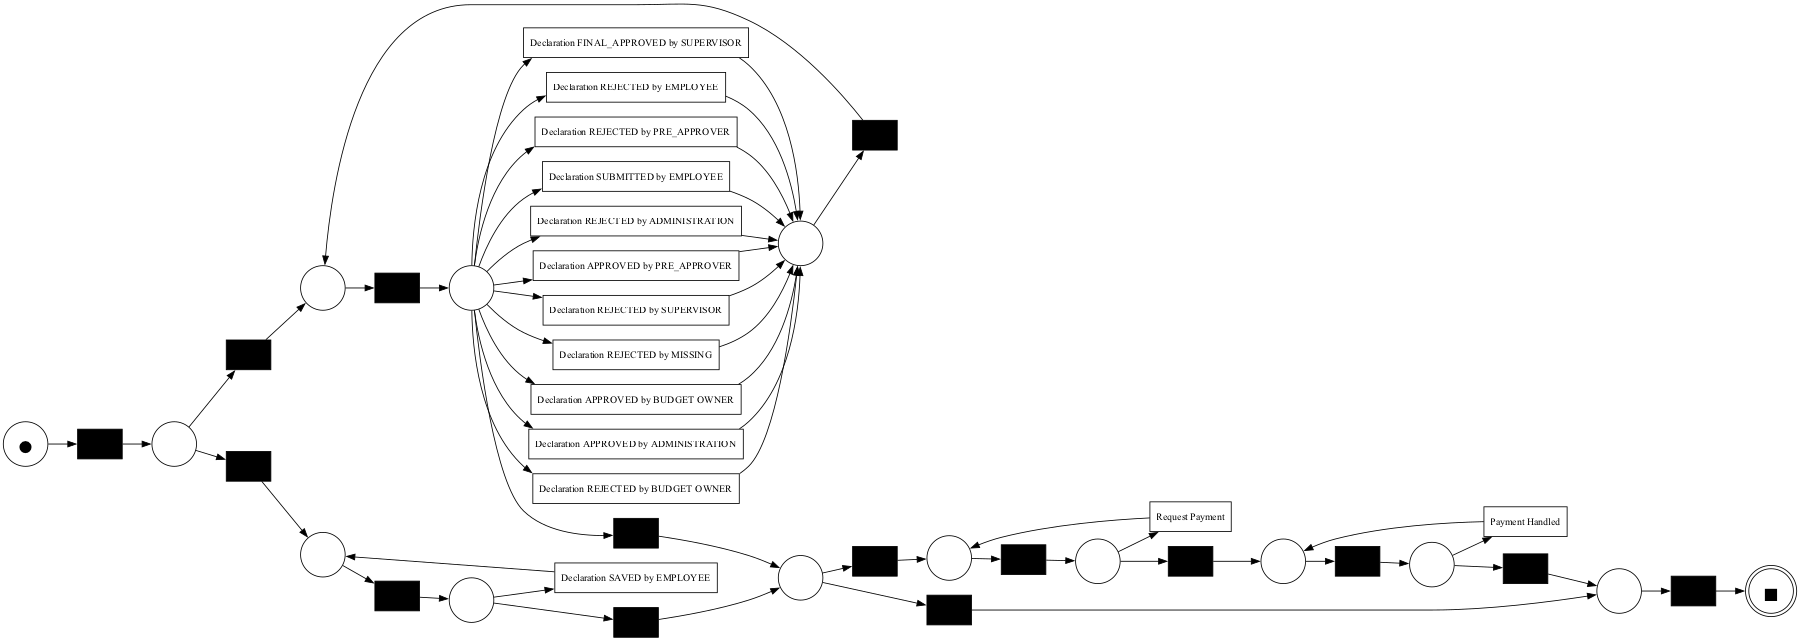


Trace Net (Combination 5)


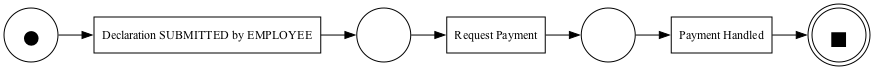


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    29.0000
  model_n_places                                    :    14.0000
  model_n_arcs                                      :    58.0000
  model_n_inv_transition                            :    15.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    14.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     6.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

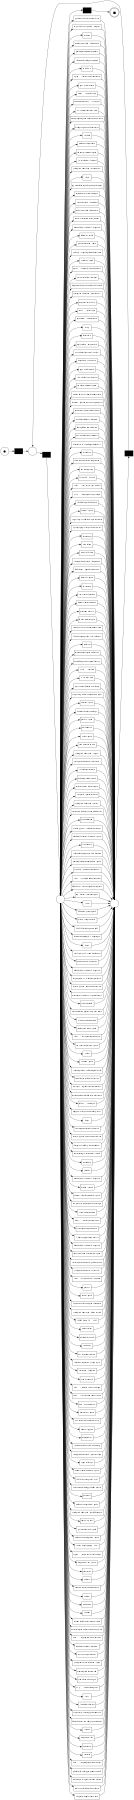


Trace Net (Combination 6)


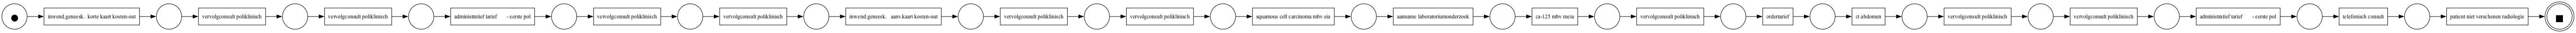


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   218.0000
  model_n_places                                    :     5.0000
  model_n_arcs                                      :   436.0000
  model_n_inv_transition                            :     4.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :   214.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

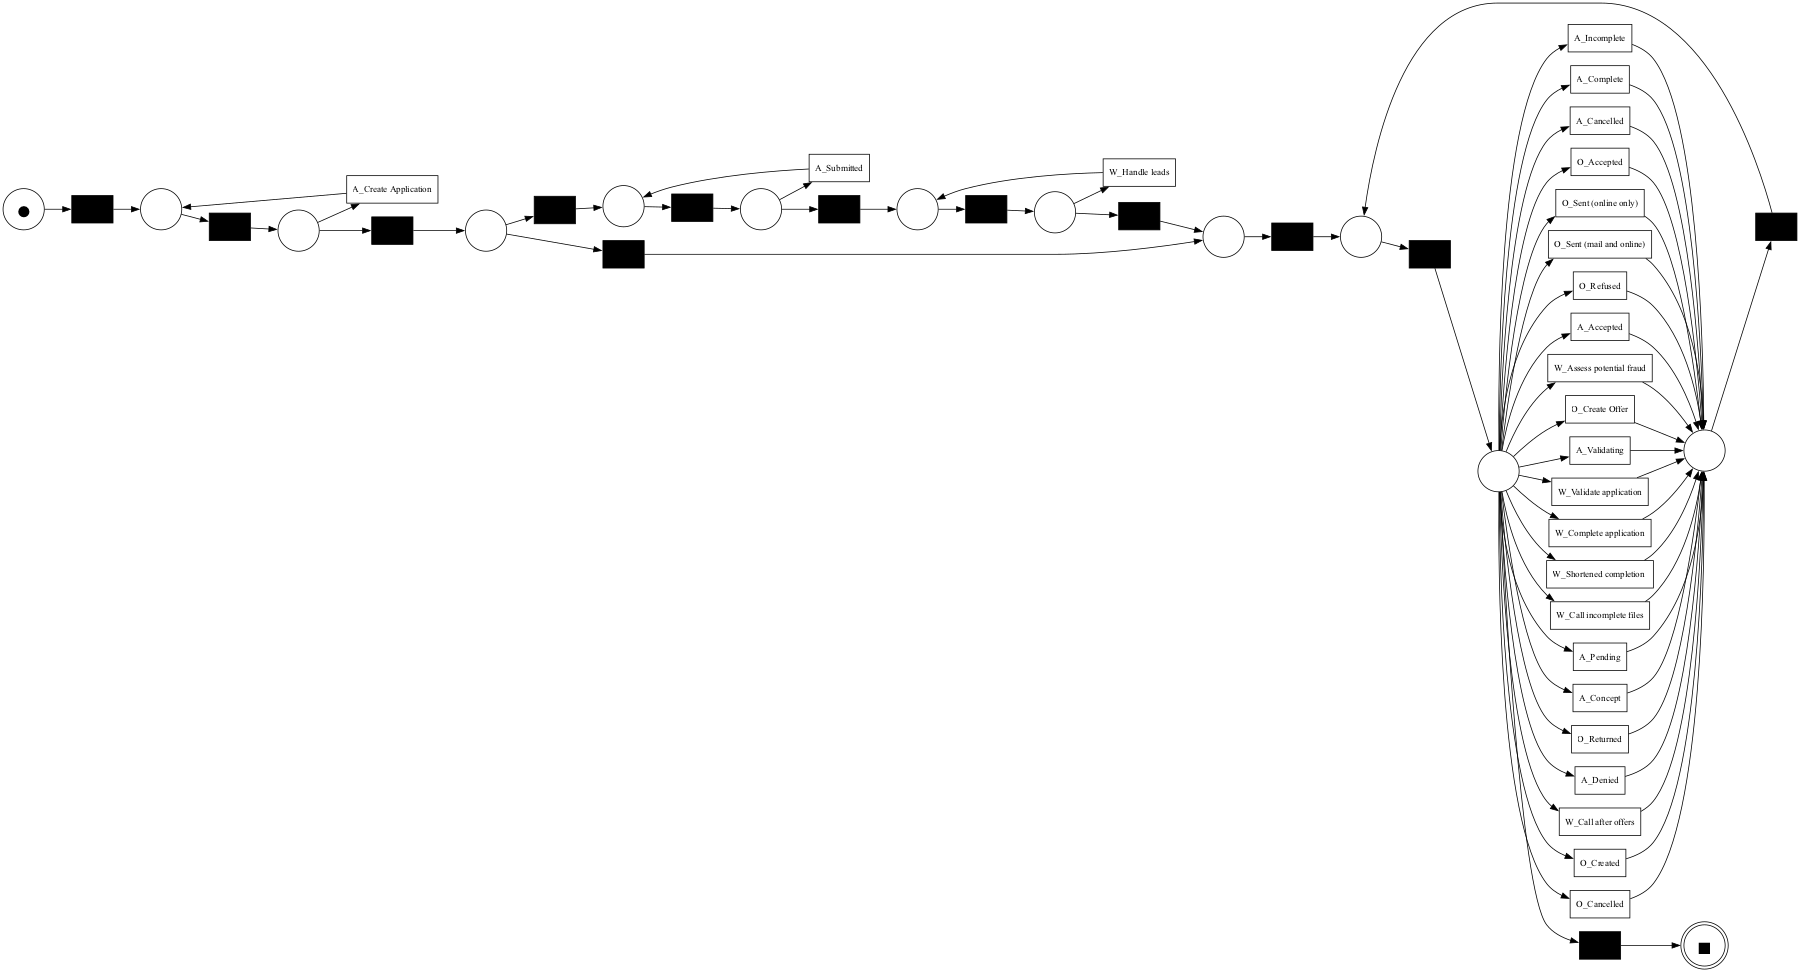


Trace Net (Combination 7)


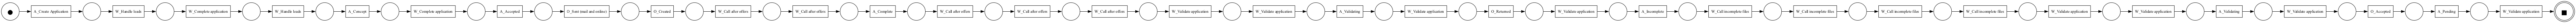


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    38.0000
  model_n_places                                    :    13.0000
  model_n_arcs                                      :    76.0000
  model_n_inv_transition                            :    13.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    25.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     5.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

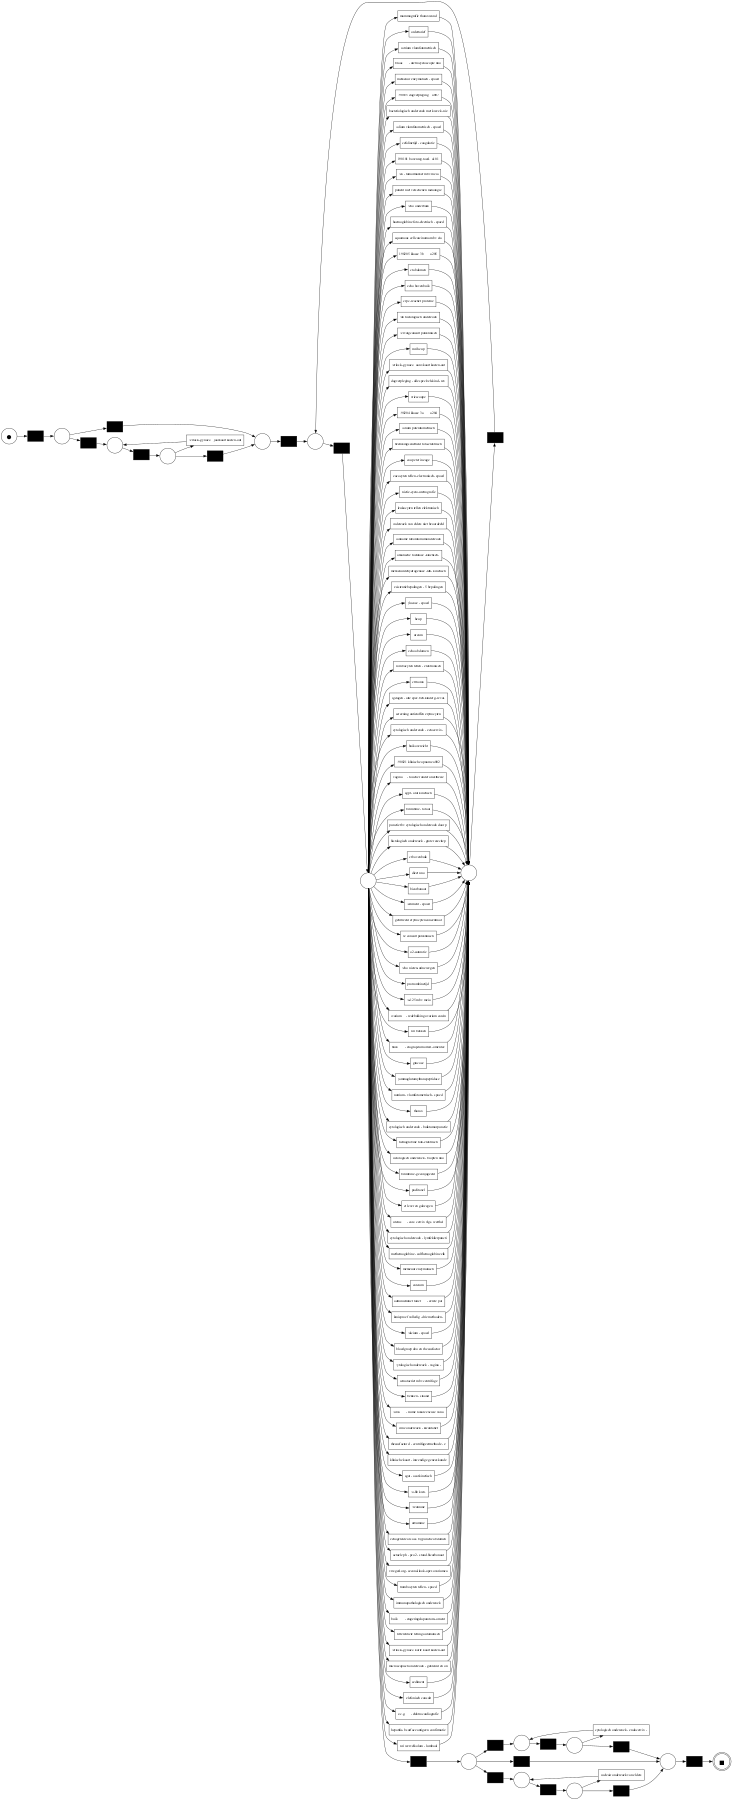


Trace Net (Combination 8)


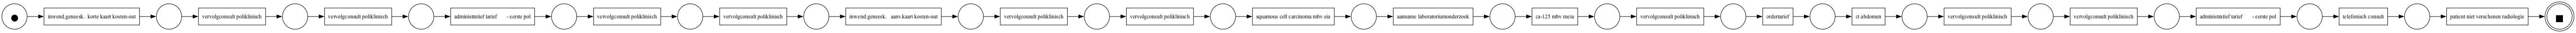


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   130.0000
  model_n_places                                    :    15.0000
  model_n_arcs                                      :   260.0000
  model_n_inv_transition                            :    17.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :   113.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     6.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

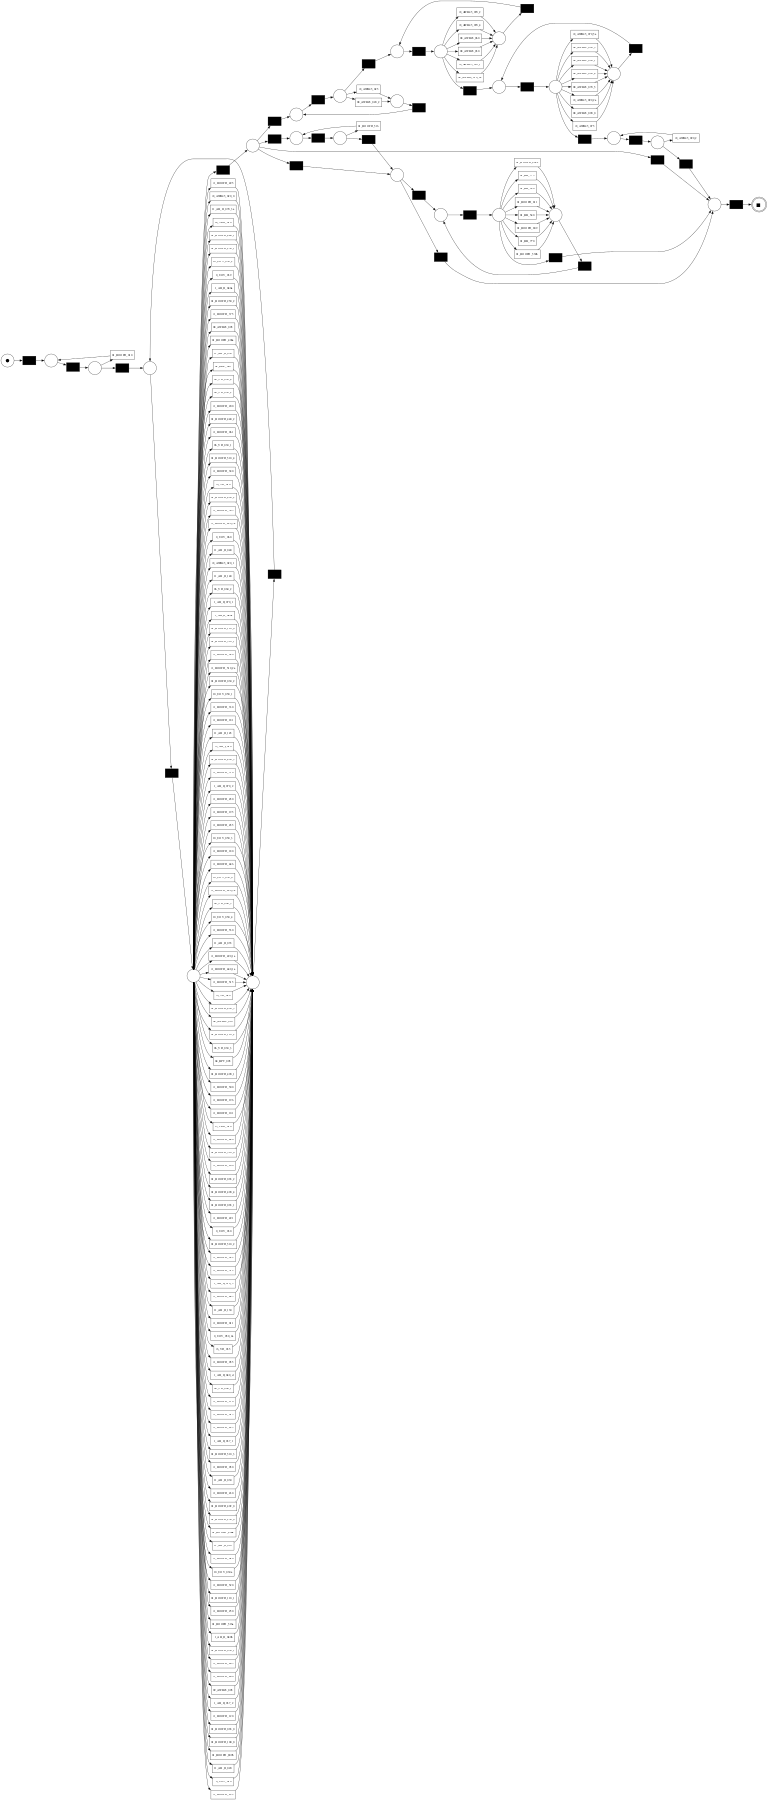


Trace Net (Combination 9)


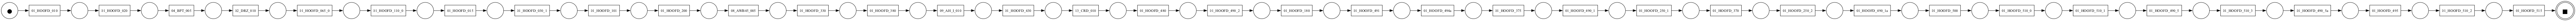


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :   180.0000
  model_n_places                                    :    26.0000
  model_n_arcs                                      :   360.0000
  model_n_inv_transition                            :    29.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :   151.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :    10.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

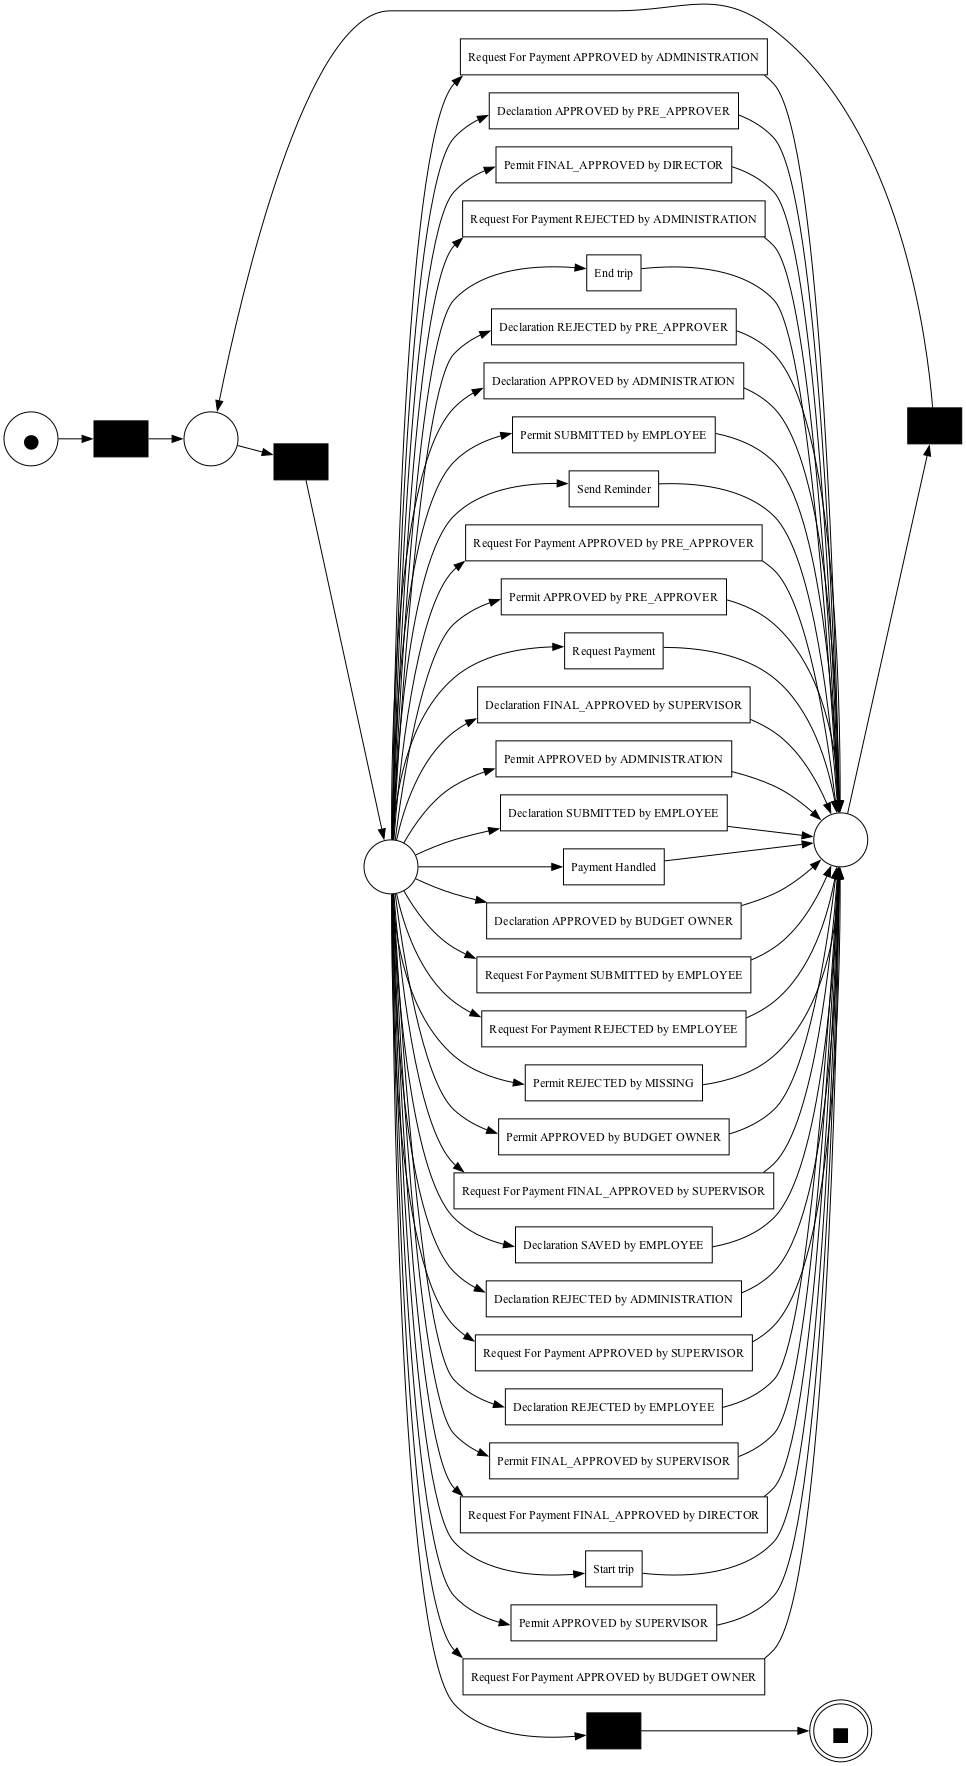


Trace Net (Combination 10)


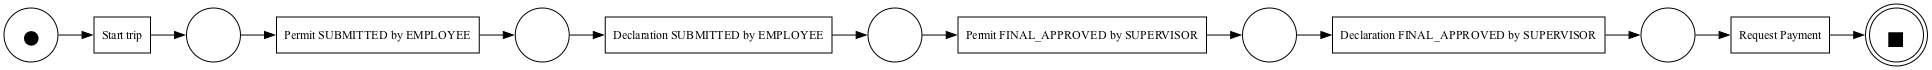


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    35.0000
  model_n_places                                    :     5.0000
  model_n_arcs                                      :    70.0000
  model_n_inv_transition                            :     4.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    31.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

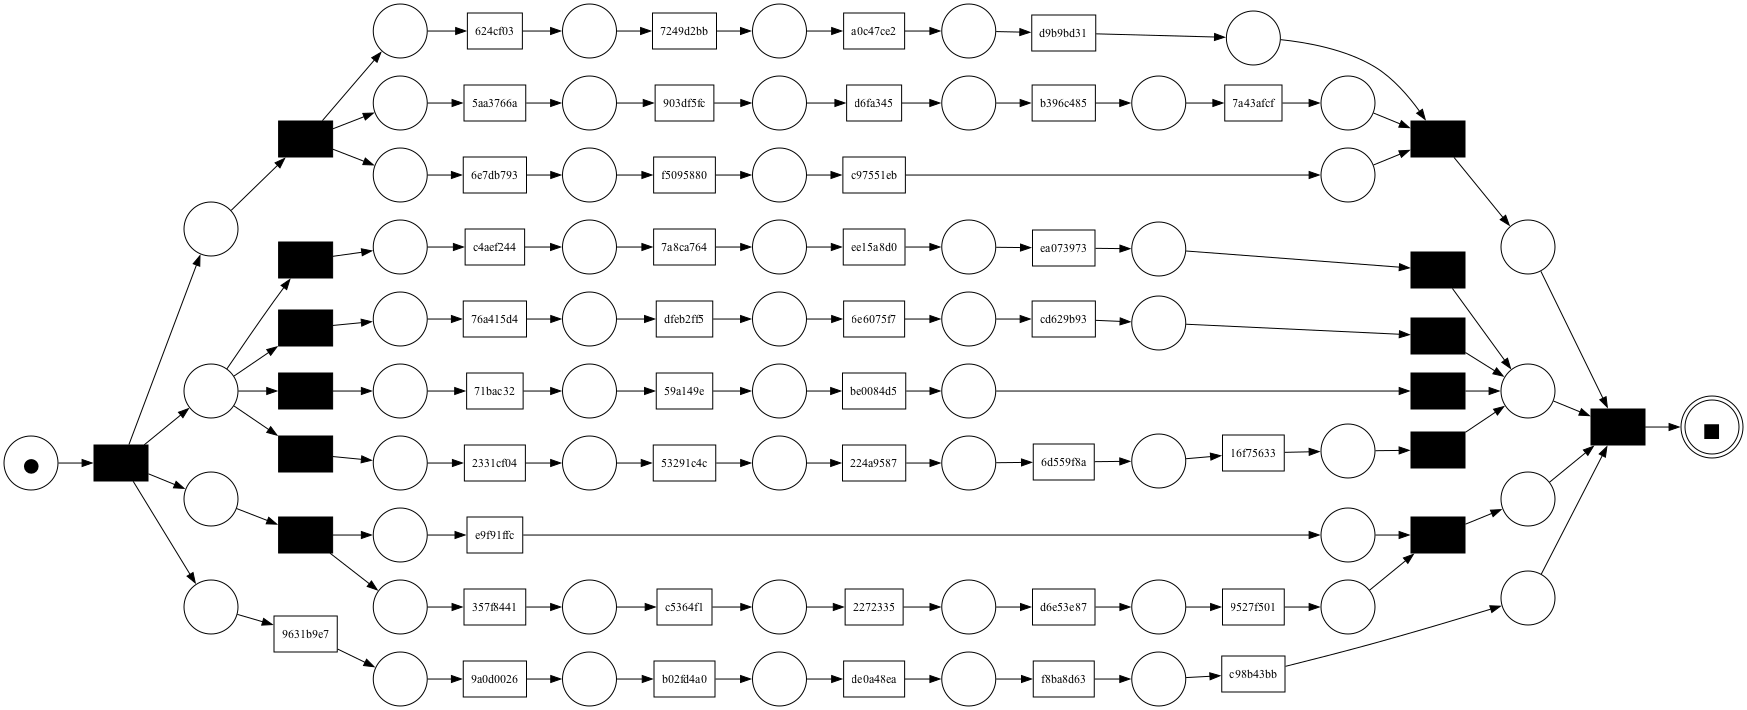


Trace Net (Combination 11)


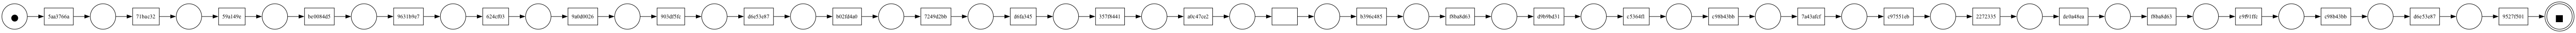


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    54.0000
  model_n_places                                    :    58.0000
  model_n_arcs                                      :   120.0000
  model_n_inv_transition                            :    14.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    40.0000
  model_n_and_split                                 :     3.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.4286
  model_inv_tran_in_deg_std                         :     0.9035
  model_inv_tran_out_deg_mean                       :     1.4286
  model_inv_tran_out_deg_std                        :     0.9035
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

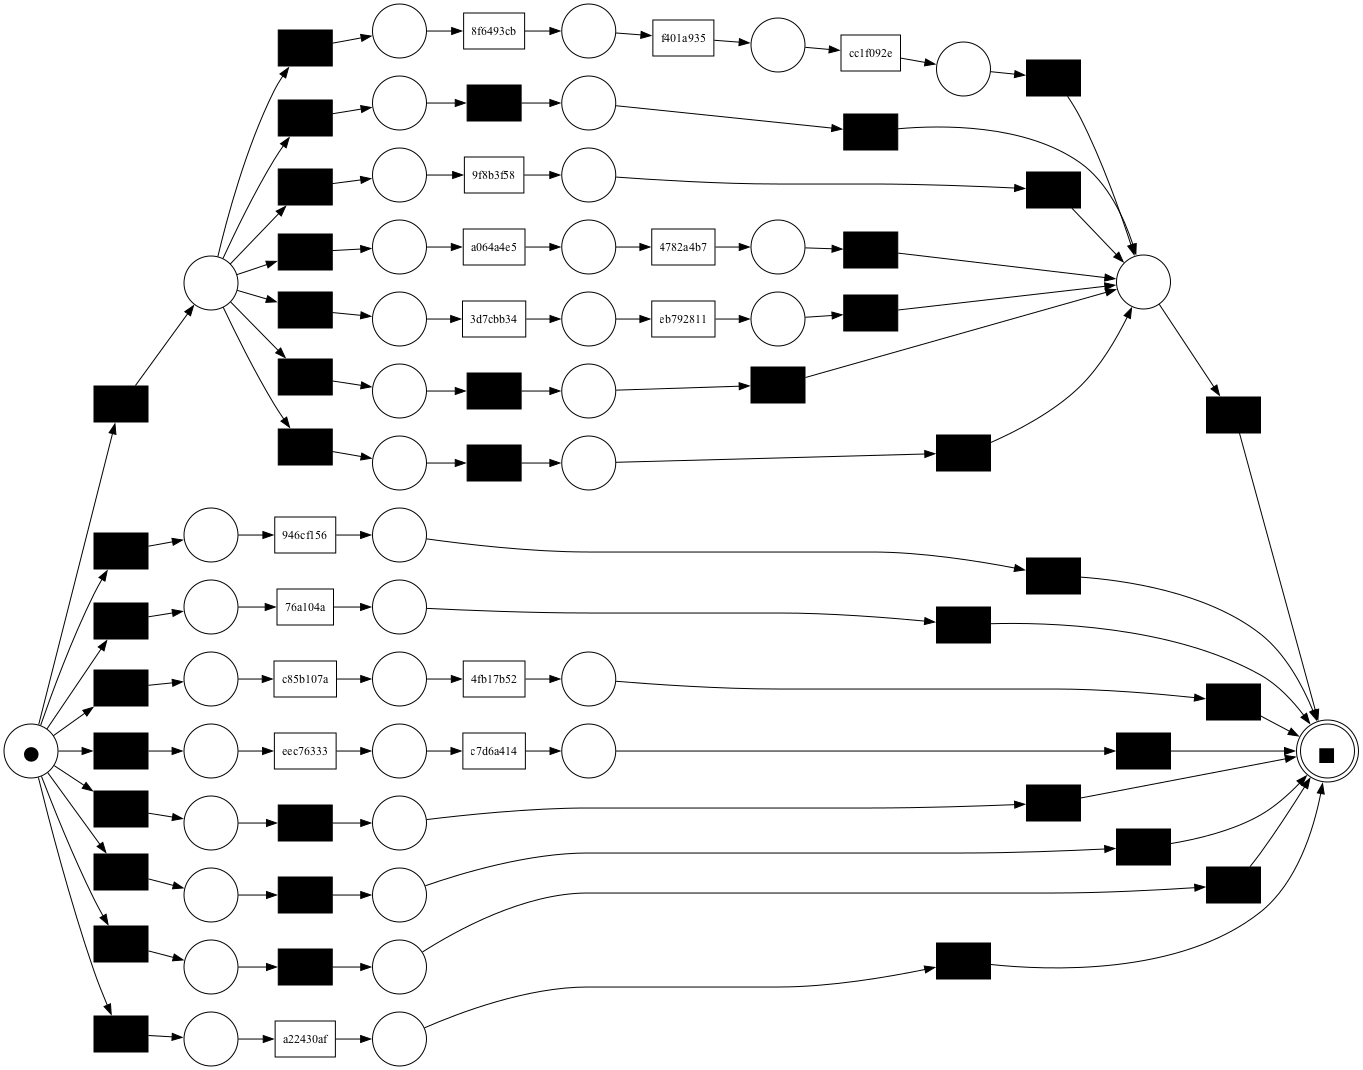


Trace Net (Combination 12)


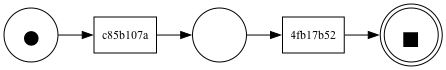


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    53.0000
  model_n_places                                    :    40.0000
  model_n_arcs                                      :   106.0000
  model_n_inv_transition                            :    38.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    15.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     2.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

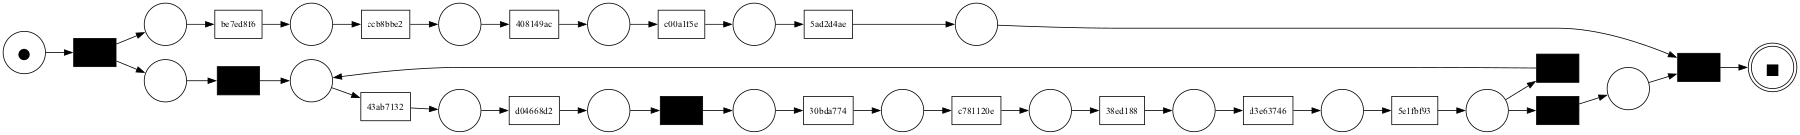


Trace Net (Combination 13)


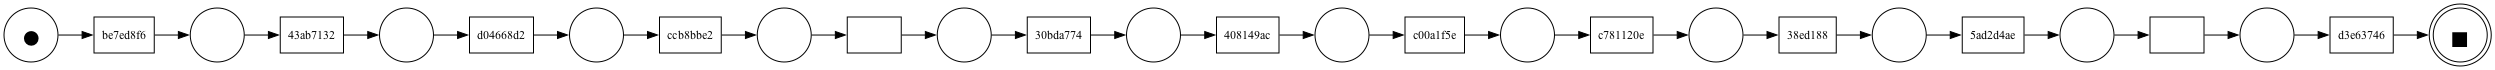


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    18.0000
  model_n_places                                    :    19.0000
  model_n_arcs                                      :    38.0000
  model_n_inv_transition                            :     6.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    12.0000
  model_n_and_split                                 :     1.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.1667
  model_inv_tran_in_deg_std                         :     0.3727
  model_inv_tran_out_deg_mean                       :     1.1667
  model_inv_tran_out_deg_std                        :     0.3727
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

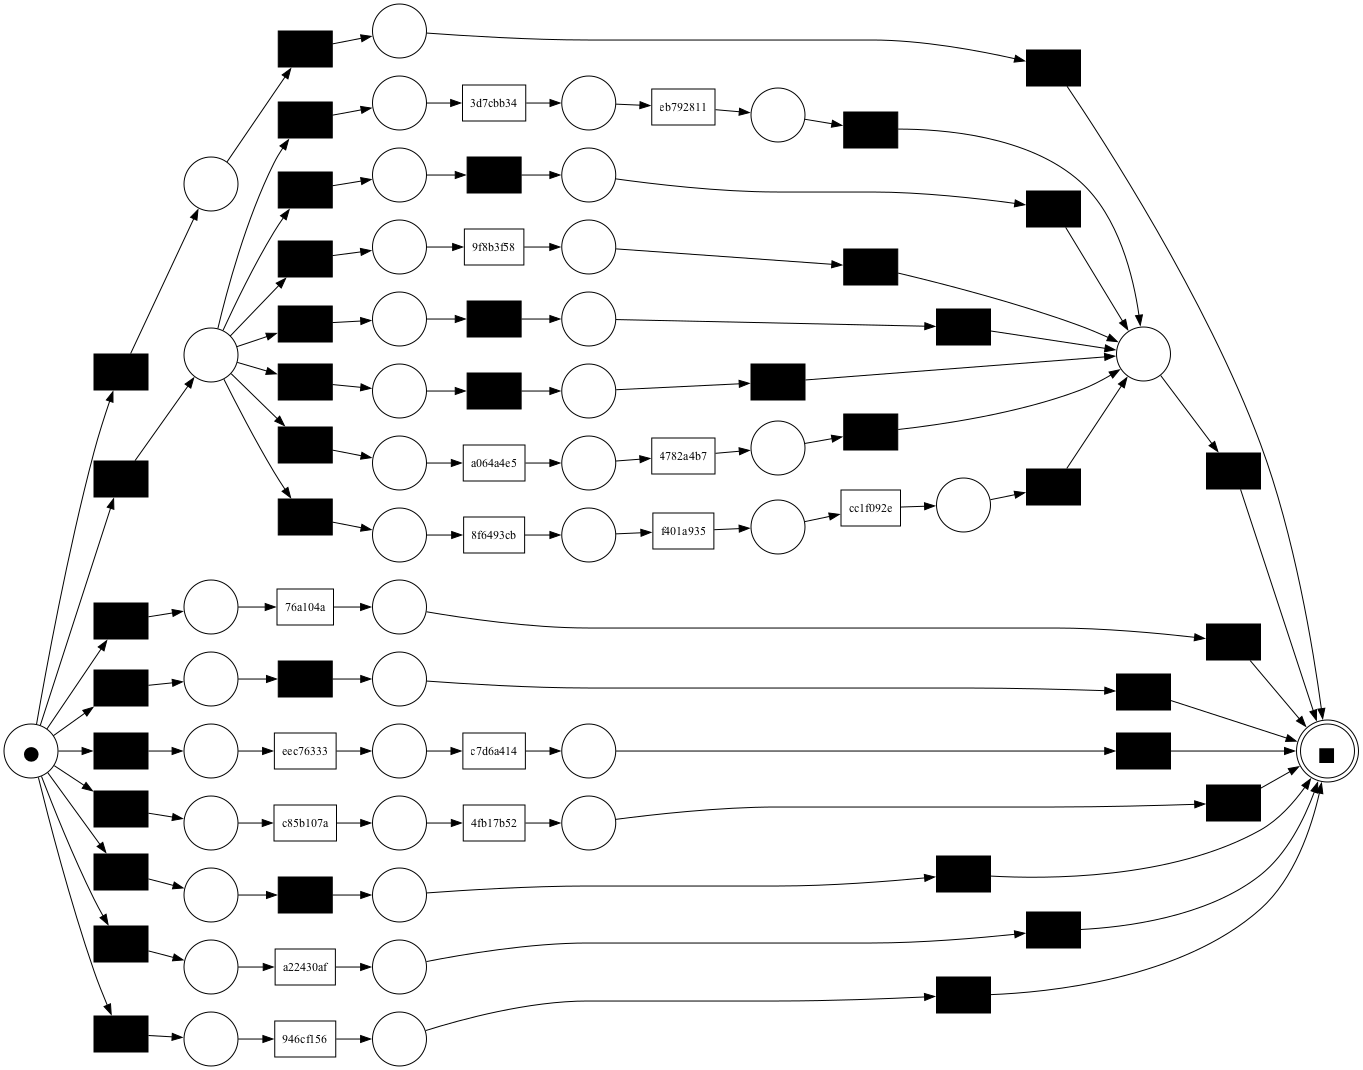


Trace Net (Combination 14)


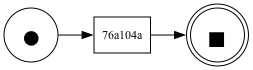


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    53.0000
  model_n_places                                    :    40.0000
  model_n_arcs                                      :   106.0000
  model_n_inv_transition                            :    38.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    15.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     2.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

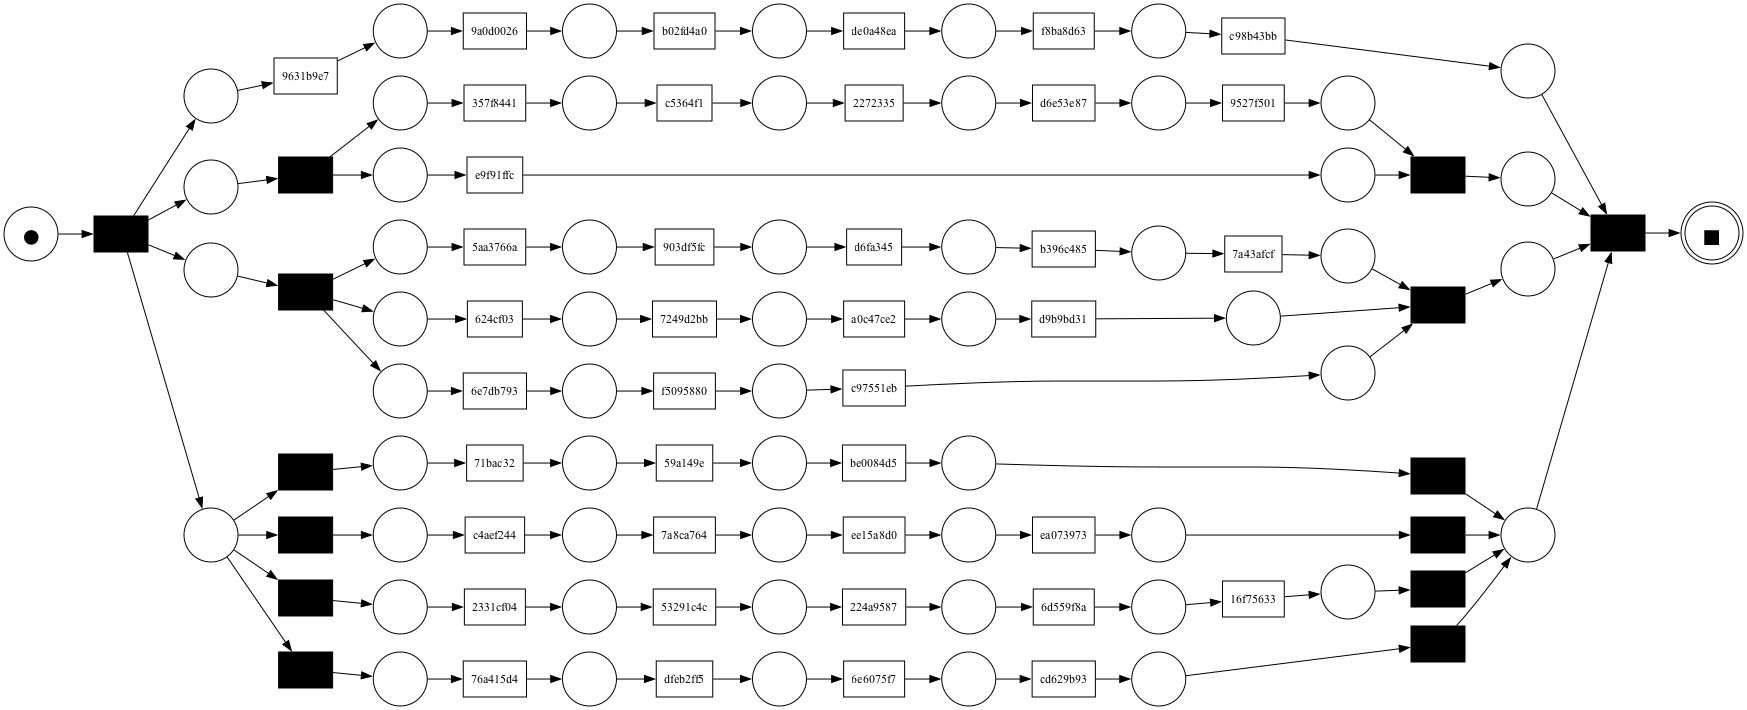


Trace Net (Combination 15)


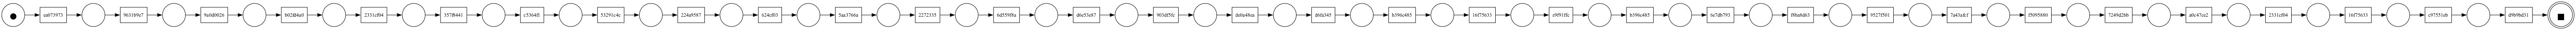


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    54.0000
  model_n_places                                    :    58.0000
  model_n_arcs                                      :   120.0000
  model_n_inv_transition                            :    14.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    40.0000
  model_n_and_split                                 :     3.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.4286
  model_inv_tran_in_deg_std                         :     0.9035
  model_inv_tran_out_deg_mean                       :     1.4286
  model_inv_tran_out_deg_std                        :     0.9035
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

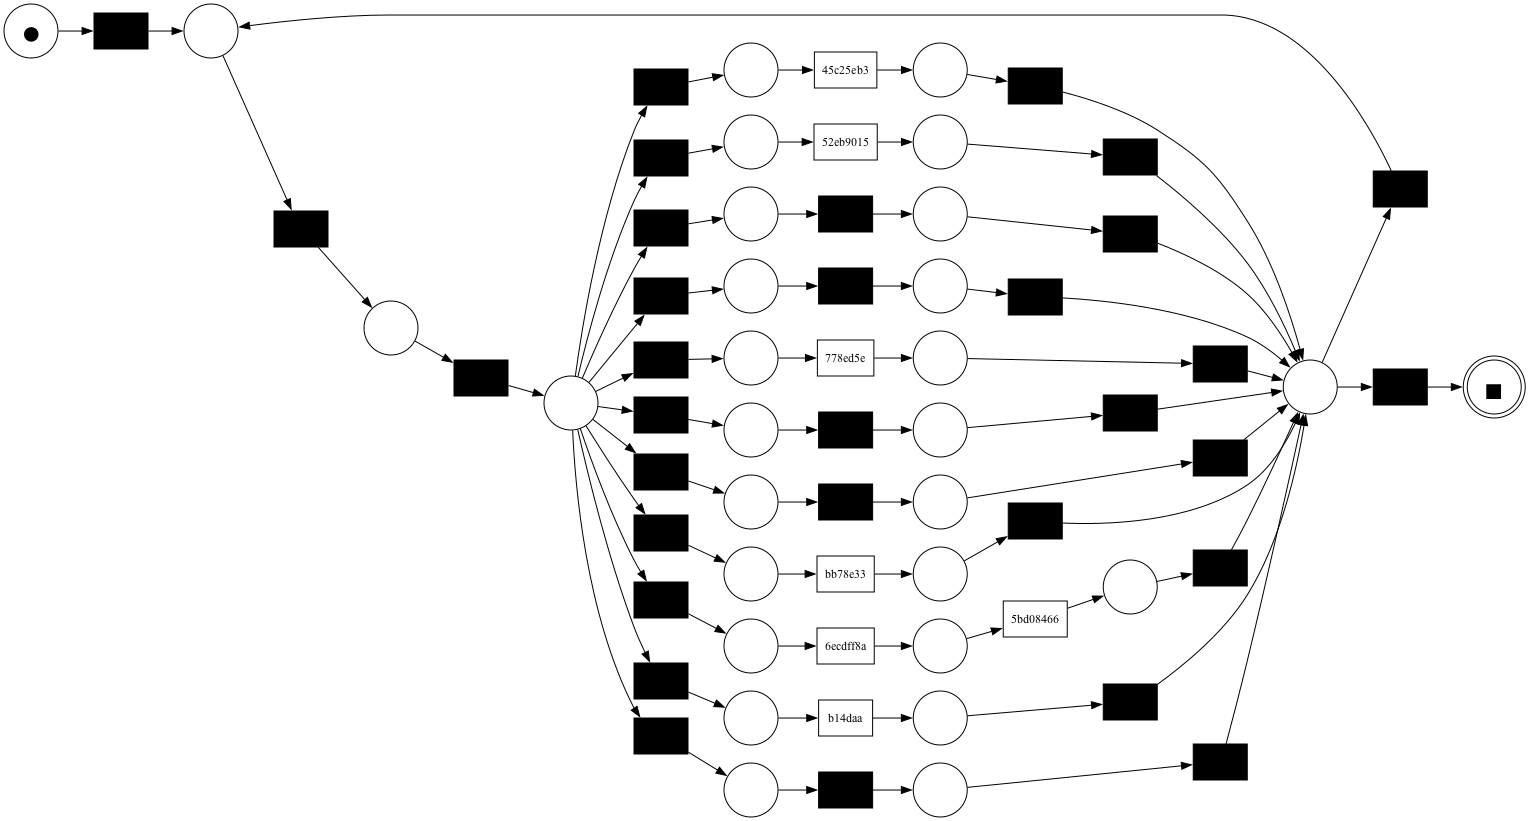


Trace Net (Combination 16)


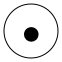


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    39.0000
  model_n_places                                    :    29.0000
  model_n_arcs                                      :    78.0000
  model_n_inv_transition                            :    32.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :     7.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     2.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

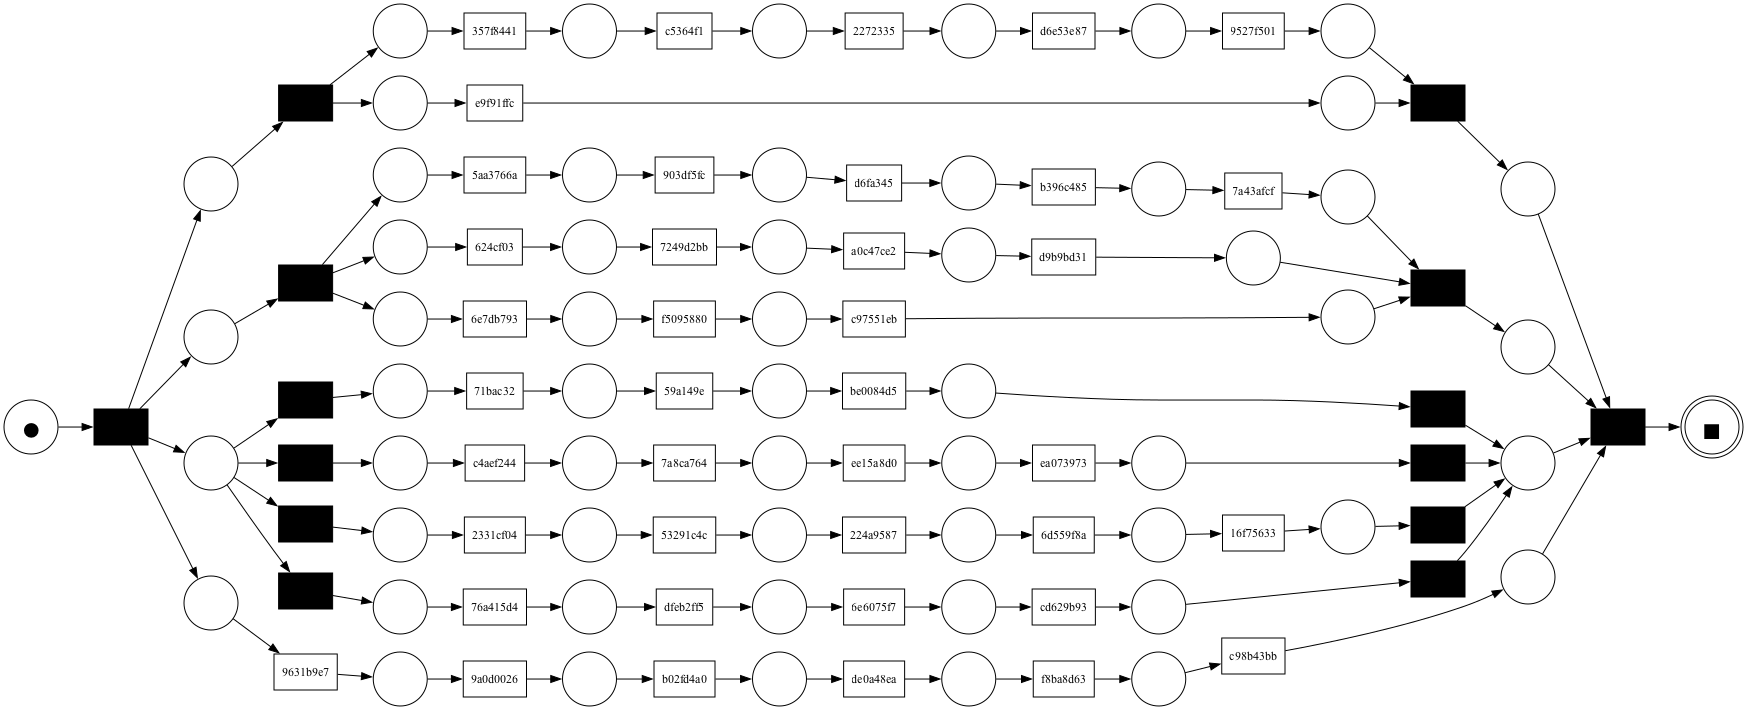


Trace Net (Combination 17)


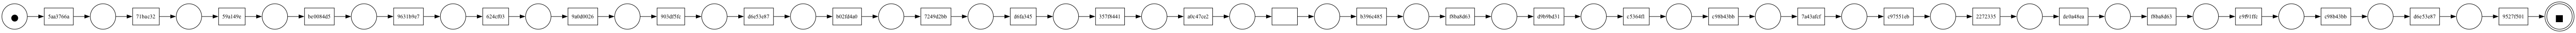


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    54.0000
  model_n_places                                    :    58.0000
  model_n_arcs                                      :   120.0000
  model_n_inv_transition                            :    14.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    40.0000
  model_n_and_split                                 :     3.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.4286
  model_inv_tran_in_deg_std                         :     0.9035
  model_inv_tran_out_deg_mean                       :     1.4286
  model_inv_tran_out_deg_std                        :     0.9035
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

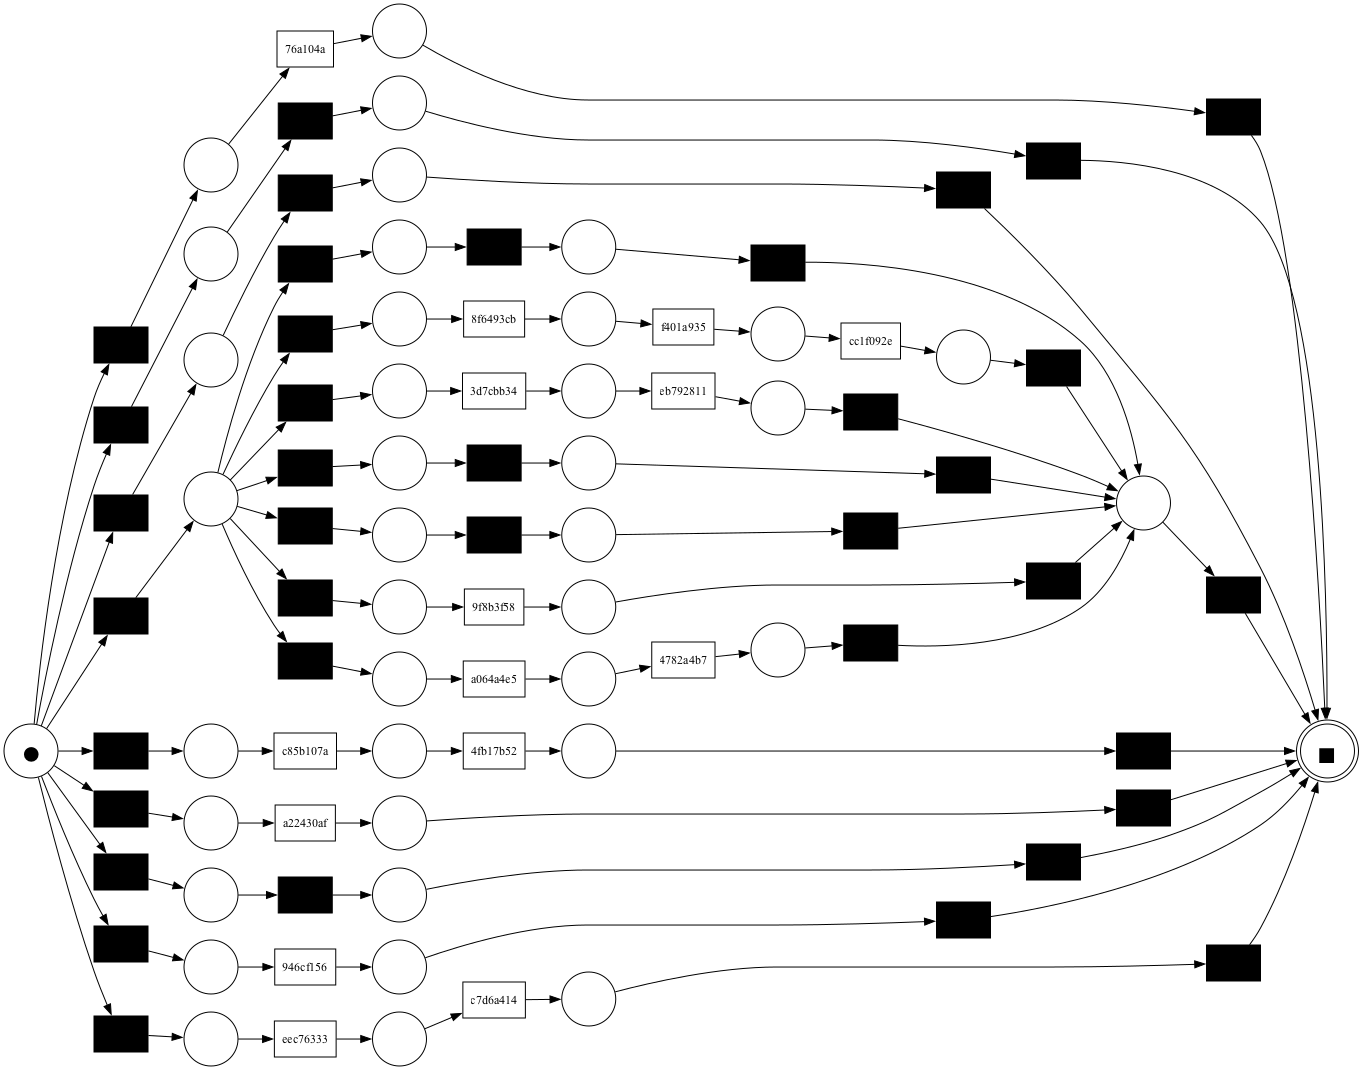


Trace Net (Combination 18)


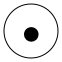


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    53.0000
  model_n_places                                    :    40.0000
  model_n_arcs                                      :   106.0000
  model_n_inv_transition                            :    38.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    15.0000
  model_n_and_split                                 :     0.0000
  model_n_xor_split                                 :     2.0000
  model_inv_tran_in_deg_mean                        :     1.0000
  model_inv_tran_in_deg_std                         :     0.0000
  model_inv_tran_out_deg_mean                       :     1.0000
  model_inv_tran_out_deg_std                        :     0.0000
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

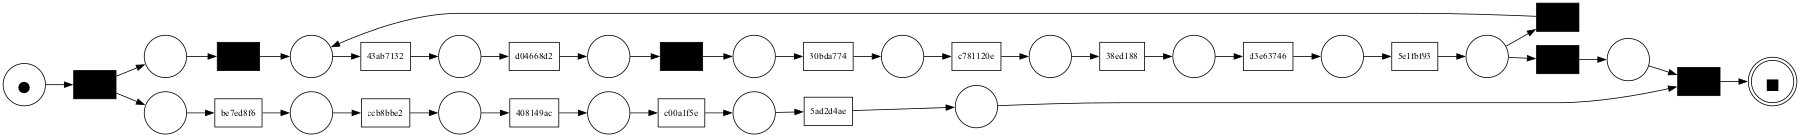


Trace Net (Combination 19)


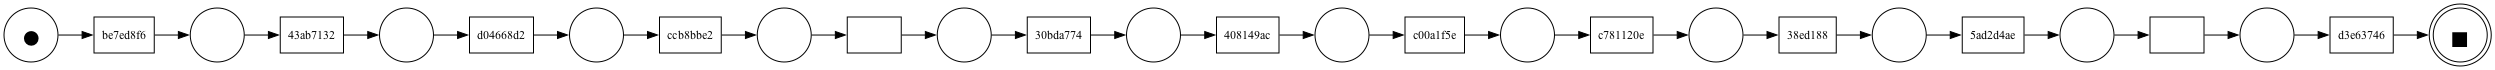


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    18.0000
  model_n_places                                    :    19.0000
  model_n_arcs                                      :    38.0000
  model_n_inv_transition                            :     6.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    12.0000
  model_n_and_split                                 :     1.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.1667
  model_inv_tran_in_deg_std                         :     0.3727
  model_inv_tran_out_deg_mean                       :     1.1667
  model_inv_tran_out_deg_std                        :     0.3727
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

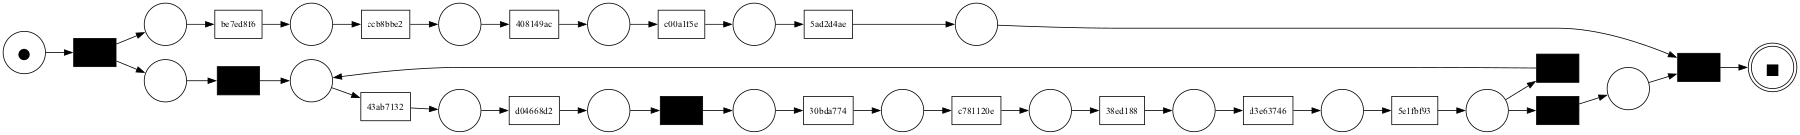


Trace Net (Combination 20)


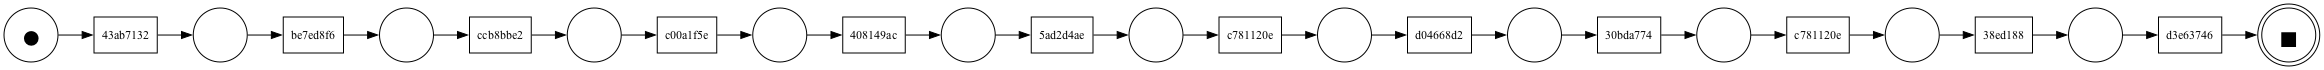


Features:
--------------------------------------------------------------------------------
  model_n_transitions                               :    18.0000
  model_n_places                                    :    19.0000
  model_n_arcs                                      :    38.0000
  model_n_inv_transition                            :     6.0000
  model_n_dup_transition                            :     0.0000
  model_n_uniq_transition                           :    12.0000
  model_n_and_split                                 :     1.0000
  model_n_xor_split                                 :     1.0000
  model_inv_tran_in_deg_mean                        :     1.1667
  model_inv_tran_in_deg_std                         :     0.3727
  model_inv_tran_out_deg_mean                       :     1.1667
  model_inv_tran_out_deg_std                        :     0.3727
  model_uniq_tran_in_deg_mean                       :     1.0000
  model_uniq_tran_in_deg_std                        :     0.000

In [12]:
# Process all RunDatasets with random sampling
import random

# Set random seed for reproducibility
random.seed(RANDOM_SEED)

for combination_counter in range(1, MAX_COMBINATIONS_TO_DISPLAY + 1):
    if combination_counter <= MAX_COMBINATIONS_TO_DISPLAY / 2:
        dataset_name, run_dataset = random.choice(real_run_datasets)
    else:
        dataset_name = "synthetic"
        run_dataset = synthetic_run_dataset
    
    random_idx = random.randint(0, len(run_dataset) - 1)
    item = run_dataset[random_idx]
    
    print(f"\n{'#'*80}")
    print(f"# Combination {combination_counter}")
    print(f"# Dataset: {dataset_name}, Item: {random_idx}")
    print(f"{'#'*80}")
    
    print(f"\n{'='*80}")
    print(f"Random Sample: {dataset_name} - Item {random_idx}")
    print(f"{'='*80}")
    
    # Extract model and trace
    pm = item.model.pm
    im = item.model.im
    fm = item.model.fm
    trace = item.trace
    
    # Basic info
    n_arcs = sum(len(p.in_arcs) + len(p.out_arcs) for p in pm.places)
    print(f"\nModel: Places={len(pm.places)}, Transitions={len(pm.transitions)}, Arcs={n_arcs}")
    
    activities = get_trace_activities(trace)
    print(f"Trace: Length={len(trace)}, Activities={activities}")
    
    trace_net, trace_im, trace_fm = construct_trace_net(trace)
    
    features_dict = feature_extractor.extract(
        pm, im, fm,
        trace_net, trace_im, trace_fm,
        return_as_dict=True
    )
    
    # Visualize model
    display_petri_net(pm, im, fm, title=f"Model (Combination {combination_counter})", max_width=25)
    
    # Visualize trace net
    display_petri_net(trace_net, trace_im, trace_fm, title=f"Trace Net (Combination {combination_counter})", max_width=100)
    
    # Display features
    display_features(features_dict)

print(f"\n{'#'*80}")
print(f"# Feature Extraction Complete")
print(f"# Processed {MAX_COMBINATIONS_TO_DISPLAY} random combinations")
print(f"{'#'*80}")